<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab J1: Chi-Squared Test for Uniform Probabilities

## Setup

In [3]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Manufacturing Cars & Lemons

### Business Decision

A car manufacturing organization produces cars 5 days per week, Monday through Friday.  We might expect that the day of the week that cars are produced has no relationship to the number of defects in those cars.  However, car buyers are sometimes warned that cars made on a Monday or a Friday have more defects on average, i.e., they are more likely to be "lemons". 

### Data

Here are the number of defects per day from a one week sample:  
Monday 32, Tuesday 22, Wednesday 26, Thursday 19, Friday 30 

Show the sample information as a table.

In [4]:
data = Table().with_columns('dow', make_array("Monday", "Tuesday","Wednesday","Thursday","Friday"),
                            'defects', make_array(32,22,26,19,30))

data

dow,defects
Monday,32
Tuesday,22
Wednesday,26
Thursday,19
Friday,30


### Analysis

Hypothesize that for the population of all cars manufactured, the proportion of defects occurring over a week is the same for every day of the week.  That would imply that the probability that a defect occurs on any specific day of the week is 20%.  The alternative to this hypothesis is that the proportion of defects occurring on some one day is different than for some
other day of the week.

In [5]:
prob_hypo = 1/data.num_rows
prob_hypo

data = data.with_column('prob_hypo', prob_hypo)
data

0.2

dow,defects,prob_hypo
Monday,32,0.2
Tuesday,22,0.2
Wednesday,26,0.2
Thursday,19,0.2
Friday,30,0.2


Calculate and show the expected number of defects for each day of the week,
based on the hypothesized probability of a defect occurring on that day of the week. 

In [6]:
data = data.with_column('defects_expected', prob_hypo*sum(data.column('defects')))
data

dow,defects,prob_hypo,defects_expected
Monday,32,0.2,25.8
Tuesday,22,0.2,25.8
Wednesday,26,0.2,25.8
Thursday,19,0.2,25.8
Friday,30,0.2,25.8


Calculate and show the sample chi-squared like this:  

$$
\chi^2 = \sum \cfrac{\left(\textit{actual} - \textit{expected}\right)^2}{\textit{expected} }
$$

In [7]:
defects = data.column('defects')
defects_expected = data.column('defects_expected')

diff = defects-defects_expected
diff_squared = diff**2
relative_diff_squared = diff_squared / defects_expected

data = data.with_columns('diff', diff, 'diff**2', diff_squared, 'relative diff**2', relative_diff_squared)
data

sample_chisquared = sum(relative_diff_squared)
sample_chisquared

dow,defects,prob_hypo,defects_expected,diff,diff**2,relative diff**2
Monday,32,0.2,25.8,6.2,38.44,1.48992
Tuesday,22,0.2,25.8,-3.8,14.44,0.55969
Wednesday,26,0.2,25.8,0.2,0.04,0.00155039
Thursday,19,0.2,25.8,-6.8,46.24,1.79225
Friday,30,0.2,25.8,4.2,17.64,0.683721


4.5271317829457365

Get 1,000,000 values from the standard chi-squared distribution for the appropriate degrees of freedom.

$$
\textit{df} = \textit{number of unique values} - 1
$$

Show the degrees of freedom, a few of the values, and a histogram of all the values (50 bins, range 0 to 25).

4

chisquared
4.28899
3.77302
1.76348
1.71409
2.21973
2.4892
11.2641
4.53553
6.96401
1.21646


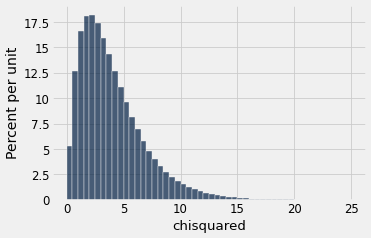

In [8]:
df = data.num_rows - 1
df

dist_array = chisquare(df, 1000000)
dist = Table().with_column('chisquared', dist_array)

dist
dist.hist(bins=50, range=make_array(0,25))

Calculate and show the probability of getting a sample with the sample chi-squared (or above), given that the hypothesis is correct (this is the p-value).
Also show the sample chi-squared and a histogram of the standard chi-squared distribution with the area corresponding to the probability highlighted.

4.5271317829457365

0.339618

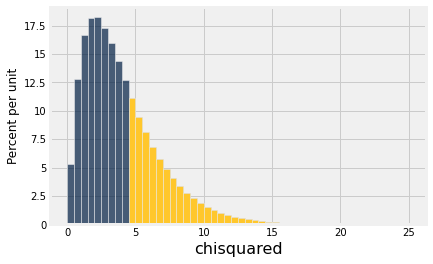

In [7]:
p_value = dist.where('chisquared', are.above_or_equal_to(sample_chisquared)).num_rows / dist.num_rows

sample_chisquared
p_value
dist.hist(bins=50, range=make_array(0,25), left_end=sample_chisquared, right_end=25)

Calculate and show the critical value at significance level 0.05.
Also show the significance level and a histogram of the standard chi-squared distribution with the area corresponding to the significance level highlighted.

0.05

9.4985304588130184

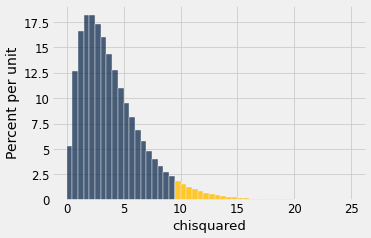

In [8]:
sig_level = 0.05
cv = percentile((1-sig_level)*100, dist.column('chisquared'))

sig_level
cv
dist.hist(bins=50, range=make_array(0,25), left_end=cv, right_end=25)

Calculate and show what to conclude about the hypothesis at significance level 0.05.

In [10]:
p_value > sig_level
sample_chisquared < cv

True

True

Accept the hypothesis. Conclude that there is no difference in number of defects based on day of the week.

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised October 27, 2023
</span>
</p>